In [11]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation

class PINN(nn.Module):
    def __init__(self, input_dim=2, output_dim=1, hidden_units=20, hidden_layers=3, activation='tanh'):
        super(PINN, self).__init__()
        
        # Define activation function
        if activation == 'tanh':
            self.activation = torch.tanh
        elif activation == 'relu':
            self.activation = F.relu
        else:
            raise ValueError(f"Unsupported activation: {activation}")
        
        # Define layers
        self.hidden_layers = nn.ModuleList()
        for _ in range(hidden_layers):
            self.hidden_layers.append(nn.Linear(hidden_units, hidden_units))
        
        self.input_layer = nn.Linear(input_dim, hidden_units)  # Input layer for 2D input
        self.output_layer = nn.Linear(hidden_units, output_dim)  # Output layer

    def forward(self, x):
        x = self.input_layer(x)  # Pass through the input layer
        for layer in self.hidden_layers:
            x = self.activation(layer(x))  # Pass through each hidden layer with activation
        x = self.output_layer(x)  # Pass through the output layer
        return x



In [12]:
def loss_I1(model1, model2, x1, f1, left_border_I1, overlap):
    """
    Loss function for subdomain I1 (2D version).
    :param model1: First model
    :param model2: Second model
    :param x1: Input tensor for subdomain I1 (2D)
    :param f1: Forcing function values for subdomain I1 (2D)
    :param I1: Boundary points for subdomain I1
    :param overlap: Overlapping points between subdomains
    :param p: Regularization parameter
    """
    x1.requires_grad = True

    # Model outputs
    u1 = model1(x1)
    u2 = model2(x1)

    # Gradients with respect to x1
    grad_u1 = torch.autograd.grad(u1, x1, grad_outputs=torch.ones_like(u1), create_graph=True)[0]
    u1_x, u1_y = grad_u1[:, 0], grad_u1[:, 1]

    grad_u1_xx = torch.autograd.grad(u1_x, x1, grad_outputs=torch.ones_like(u1_x), create_graph=True)[0][:, 0]
    grad_u1_yy = torch.autograd.grad(u1_y, x1, grad_outputs=torch.ones_like(u1_y), create_graph=True)[0][:, 1]

    laplacian_u1 = grad_u1_xx + grad_u1_yy

    # Interior loss
    interior_loss = torch.mean((u1 - laplacian_u1 + f1) ** 2)

    # Boundary condition
    # Ensure left_border_I1 is a tensor
    if isinstance(left_border_I1, list):
        left_border_I1 = torch.tensor(left_border_I1, dtype=torch.float32)

    bc1 = torch.mean((model1(left_border_I1)- 0) ** 2)

    # Transmission conditions
    right_tc1 = torch.mean((model1(overlap[1])- model2(overlap[1])) ** 2)
    top_tc1 = torch.mean((model1(overlap[2])- model2(overlap[2])) ** 2)
    bottom_tc1 = torch.mean((model1(overlap[3])- model2(overlap[3])) ** 2)
    
    Tc1 = right_tc1 + top_tc1 + bottom_tc1

    # Total loss
    loss = interior_loss + bc1 + Tc1
    return loss

def loss_I2(model1, model2, x2, f2, right_border_I2, overlap):
    """
    Loss function for subdomain I2 (2D version).
    :param model1: First model
    :param model2: Second model
    :param x2: Input tensor for subdomain I2 (2D)
    :param f2: Forcing function values for subdomain I2 (2D)
    :param I2: Boundary points for subdomain I2
    :param overlap: Overlapping points between subdomains
    :param q: Regularization parameter
    """
    x2.requires_grad = True

    # Model outputs
    u2 = model2(x2)
    u1 = model1(x2)

    # Gradients with respect to x2
    grad_u2 = torch.autograd.grad(u2, x2, grad_outputs=torch.ones_like(u2), create_graph=True)[0]
    u2_x, u2_y = grad_u2[:, 0], grad_u2[:, 1]

    grad_u2_xx = torch.autograd.grad(u2_x, x2, grad_outputs=torch.ones_like(u2_x), create_graph=True)[0][:, 0]
    grad_u2_yy = torch.autograd.grad(u2_y, x2, grad_outputs=torch.ones_like(u2_y), create_graph=True)[0][:, 1]

    laplacian_u2 = grad_u2_xx + grad_u2_yy

    # Interior loss
    interior_loss = torch.mean((u2 - laplacian_u2 - f2) ** 2)

    # Boundary condition
    # Ensure left_border_I1 is a tensor
    if isinstance(left_border_I1, list):
        right_border_I2 = torch.tensor(right_border_I2, dtype=torch.float32)

    bc2 = torch.mean((model2(right_border_I2)- 0) ** 2)
    

     # Transmission conditions
    left_tc2 = torch.mean((model2(overlap[0])- model1(overlap[0])) ** 2)
    top_tc2 = torch.mean((model2(overlap[2])- model1(overlap[2])) ** 2)
    bottom_tc2 = torch.mean((model2(overlap[3])- model1(overlap[3])) ** 2)
    
    Tc2 = left_tc2 + top_tc2 + bottom_tc2

   

    # Total loss
    loss = interior_loss + bc2 + Tc2
    return loss


In [13]:
# Instantiate models for each subdomain
model1 = PINN(hidden_units=20, hidden_layers=2, activation='tanh')
model2 = PINN(hidden_units=20, hidden_layers=2, activation='tanh')

# Initialize models by passing dummy input
np.random.seed(42)
dummy_input = torch.tensor(np.random.randn(1, 2), dtype=torch.float32)
_ = model1(dummy_input)  # Initialize weights for model1
_ = model2(dummy_input)  # Initialize weights for model2

# Save initial weights
initial_weights_model1 = {name: param.clone() for name, param in model1.named_parameters()}
initial_weights_model2 = {name: param.clone() for name, param in model2.named_parameters()}

In [14]:

deltas = [0.5, 0.3, 0.1, 1e-2, 1e-3]

In [15]:

# Define the 2D domain and subdomains
Iter = []

for h in deltas:
    print(f"For delta = {h}")
    I = [-1, 1, -1, 1]  # Domain bounds: [x_min, x_max, y_min, y_max]
    I1 = [-1, h, -1, 1]  # Subdomain I1 bounds
    I2 = [0, 1, -1, 1]  # Subdomain I2 bounds
    overlap = [0, h, -1, 1]  # Overlapping region bounds
    N1 = 100  # Number of training points in each subdomain
    N2 = 100
    
    
    # Generate training points for each subdomain
    x1 = torch.tensor(
        np.stack(np.meshgrid(np.linspace(I1[0], I1[1], int(np.sqrt(N1))),
                             np.linspace(I1[2], I1[3], int(np.sqrt(N1)))), -1).reshape(-1, 2),
        dtype=torch.float32,
        requires_grad=True
    )
    x2 = torch.tensor(
        np.stack(np.meshgrid(np.linspace(I2[0], I2[1], int(np.sqrt(N2))),
                             np.linspace(I2[2], I2[3], int(np.sqrt(N2)))), -1).reshape(-1, 2),
        dtype=torch.float32,
        requires_grad=True
    )
    
    
    #--------------------------------------Overlaping grid points------------------------------------------------------
    
    left_ovl_border = x2[x2[:, 0] == overlap[0]]  
    right_ovl_border = x1[x1[:, 0] == overlap[1]]
    
    top_ovl_border = x2[((x2[:, 0] >= overlap[0]) & (x2[:, 0] <= overlap[1])) & (x2[:, 1] == overlap[3])]  
    bottom_ovl_border = x2[((x2[:, 0] >= overlap[0]) & (x2[:, 0] <= overlap[1])) & (x2[:, 1] == overlap[2])] 
    
    overlap_grid = [left_ovl_border, right_ovl_border, top_ovl_border, bottom_ovl_border]
    
    #------------------------------Extrem borders--------------------------------------------------------------------
    left_border_I1 = x1[x1[:, 0] == I1[0]]  # Points où x = I1[0]
    
    right_border_I2 = x2[x2[:, 0] == I2[3]]  # Points où x = I1[0]
    



    
    #--------------------------------------Generate prediction test data----------------------------------
    x1_test_tensor = torch.tensor(
        np.stack(np.meshgrid(np.linspace(I1[0], I1[1], 50),
                             np.linspace(I1[2], I1[3], 50)), -1).reshape(-1, 2),
        dtype=torch.float32
    )
    x2_test_tensor = torch.tensor(
        np.stack(np.meshgrid(np.linspace(I2[0], I2[1], 50),
                             np.linspace(I2[2], I2[3], 50)), -1).reshape(-1, 2),
        dtype=torch.float32
    )
    
    # Function f1 and f2
    f1 = torch.zeros(x1.size(0), dtype=torch.float32)
    f2 = torch.zeros(x2.size(0), dtype=torch.float32)
    
    # Reset the models to their initial weights
    model1.load_state_dict(initial_weights_model1)
    model2.load_state_dict(initial_weights_model2)
    
    # Training loop with while condition
    tol = 1e-5
    losses1 = []
    losses2 = []
    epoch = 0
    
    # Define optimizers
    optimizer1 = Adam(model1.parameters(), lr=1e-3)
    optimizer2 = Adam(model2.parameters(), lr=1e-3)
    
    while True:
        # Train model1
        optimizer1.zero_grad()
        loss1 = loss_I1(model1, model2, x1, f1, left_border_I1, overlap_grid)
        loss1.backward(retain_graph=True)
        optimizer1.step()
    
        # Train model2
        optimizer2.zero_grad()
        loss2 = loss_I2(model1, model2, x2, f2, right_border_I2, overlap_grid)
        loss2.backward(retain_graph=True)
        optimizer2.step()
    
        losses1.append(loss1.item())
        losses2.append(loss2.item())
    
        if epoch % 50 == 0:
            print(f"Epoch {epoch}, Loss1: {loss1.item()}, Loss2: {loss2.item()}")
    
        epoch += 1
    
        if epoch == 1:
            u1_first_pred = model1(x1_test_tensor).detach().numpy()
            u2_first_pred = model2(x2_test_tensor).detach().numpy()
    
        if loss1.item() + loss2.item() < tol:
            Iter.append(epoch)
            print(f"Last Epoch {epoch}, Loss1: {loss1.item()}, Loss2: {loss2.item()}")
            print("\n")
            break


For delta = 0.5
Epoch 0, Loss1: 0.26133957505226135, Loss2: 0.09068344533443451
Epoch 50, Loss1: 0.0008373846067115664, Loss2: 0.000384861312340945
Epoch 100, Loss1: 0.0003022821038030088, Loss2: 7.549668953288347e-05
Epoch 150, Loss1: 0.00015542983601335436, Loss2: 3.9216734876390547e-05
Epoch 200, Loss1: 9.261543164029717e-05, Loss2: 2.452399712637998e-05
Epoch 250, Loss1: 6.0250597016420215e-05, Loss2: 1.7315198419964872e-05
Epoch 300, Loss1: 4.193557833787054e-05, Loss2: 1.3648303138324991e-05
Epoch 350, Loss1: 3.060754534089938e-05, Loss2: 1.1444051779108122e-05
Epoch 400, Loss1: 2.3029495423543267e-05, Loss2: 9.839359336183406e-06
Epoch 450, Loss1: 1.764618355082348e-05, Loss2: 8.523478754796088e-06
Epoch 500, Loss1: 1.366954074910609e-05, Loss2: 7.3883684308384545e-06
Epoch 550, Loss1: 1.0670608389773406e-05, Loss2: 6.393400326487608e-06
Epoch 600, Loss1: 8.391211849811953e-06, Loss2: 5.519019396160729e-06
Epoch 650, Loss1: 6.657849553448614e-06, Loss2: 4.7521361921099015e-06
La

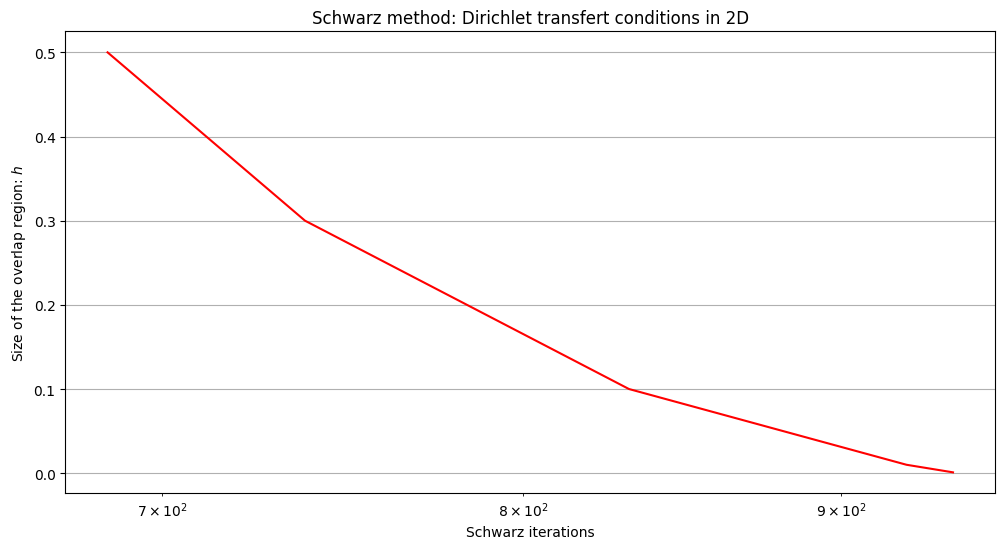

In [16]:
plt.figure( figsize=(12, 6))
plt.plot(Iter, deltas, "red")
plt.xlabel("Schwarz iterations")
plt.ylabel("Size of the overlap region: $h$")
plt.xscale("log")
#plt.yscale("log")
plt.title("Schwarz method: Dirichlet transfert conditions in 2D")
plt.grid(True)

In [17]:
#-----------------Prediction grid data for p------------------------#
x1_all = np.meshgrid(np.linspace(I1[0], I1[1], 50),np.linspace(I1[2], I1[3], 50))
x2_all = np.meshgrid(np.linspace(I2[0], I2[1], 50),np.linspace(I2[2], I2[3], 50))
X_x1, Y_x1 = x1_all
X_x2, Y_x2 = x2_all

#-------------Reshaping of data into list--------------#
u1_first_pred = u1_first_pred.reshape(X_x1.shape)
u2_first_pred = u2_first_pred.reshape(X_x2.shape)

> ## First iteration

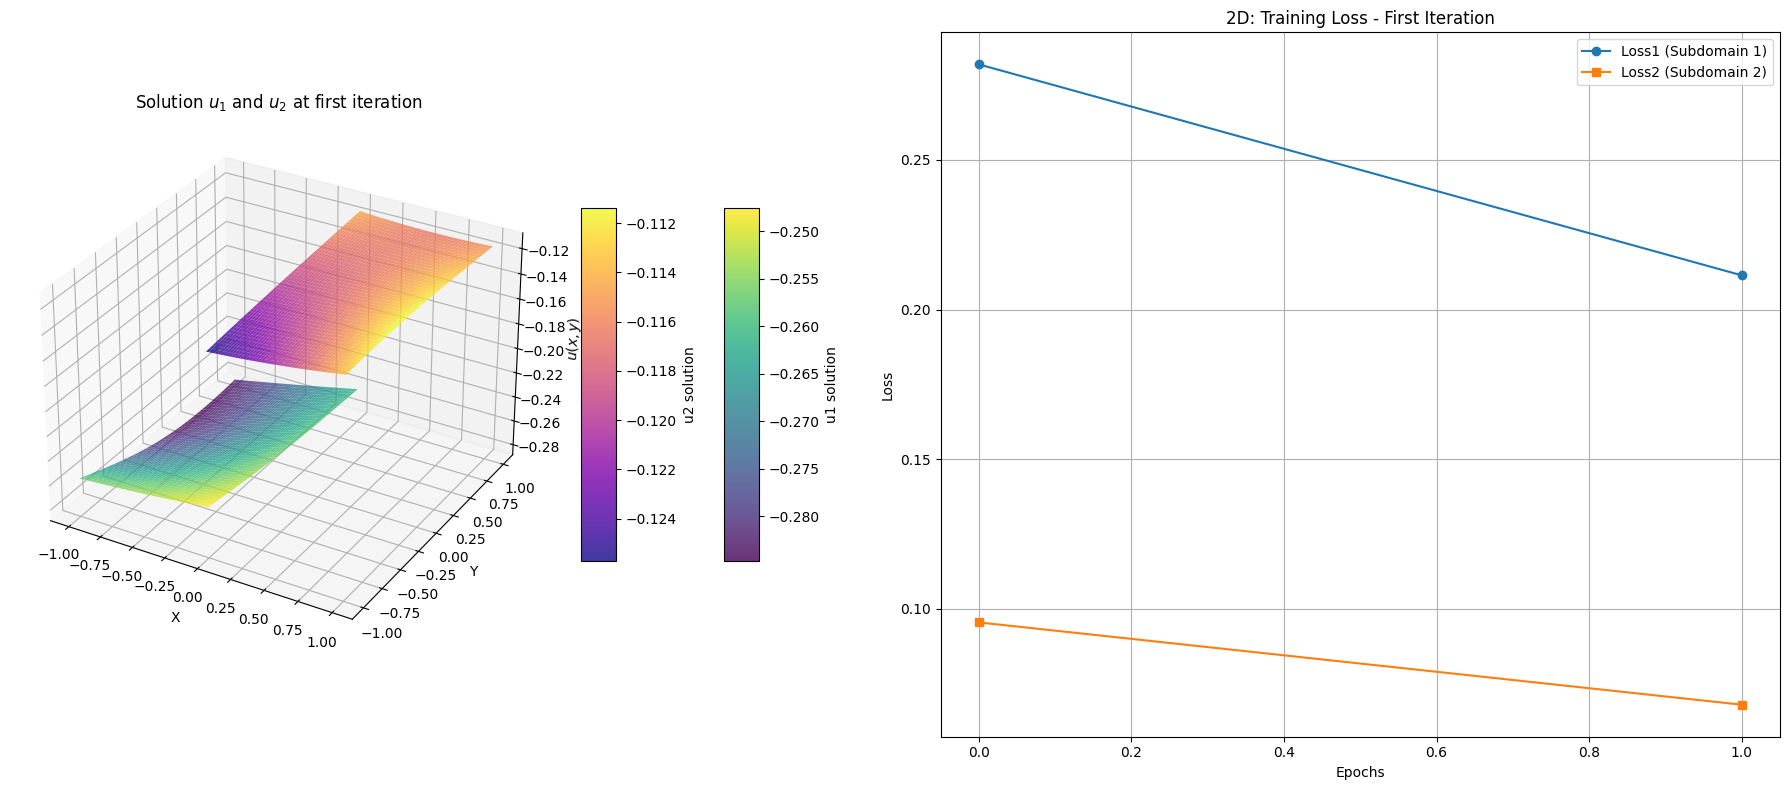

In [20]:
import plotly.subplots as sp
import plotly.graph_objects as go

# Afficher les deux surfaces sur une seule figure
fig = plt.figure(figsize=(18, 8))
ax1 = fig.add_subplot(121, projection='3d')

# Tracer la première surface
surface1 = ax1.plot_surface(X_x1, Y_x1, u1_first_pred, cmap='viridis', edgecolor='none', alpha=0.8, label="f1(x, y)")

# Tracer la deuxième surface
surface2 = ax1.plot_surface(X_x2, Y_x2, u2_first_pred, cmap='plasma', edgecolor='none', alpha=0.8, label="f2(x, y)")

# Ajouter les étiquettes et une légende
ax1.set_xlabel('X')
ax1.set_ylabel('Y')
ax1.set_zlabel('$u(x,y)$')

ax1.set_title("Solution $u_1$ and $u_2$ at first iteration")


fig.colorbar(surface1, shrink=0.5, aspect=10, label="u1 solution")
fig.colorbar(surface2, shrink=0.5, aspect=10, label="u2 solution")

ax2 = fig.add_subplot(122)
ax2.plot(losses1[:2], label='Loss1 (Subdomain 1)', marker='o')
ax2.plot(losses2[:2], label='Loss2 (Subdomain 2)', marker='s')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Loss')
ax2.set_title('2D: Training Loss - First Iteration')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()


> # Last Prediction 

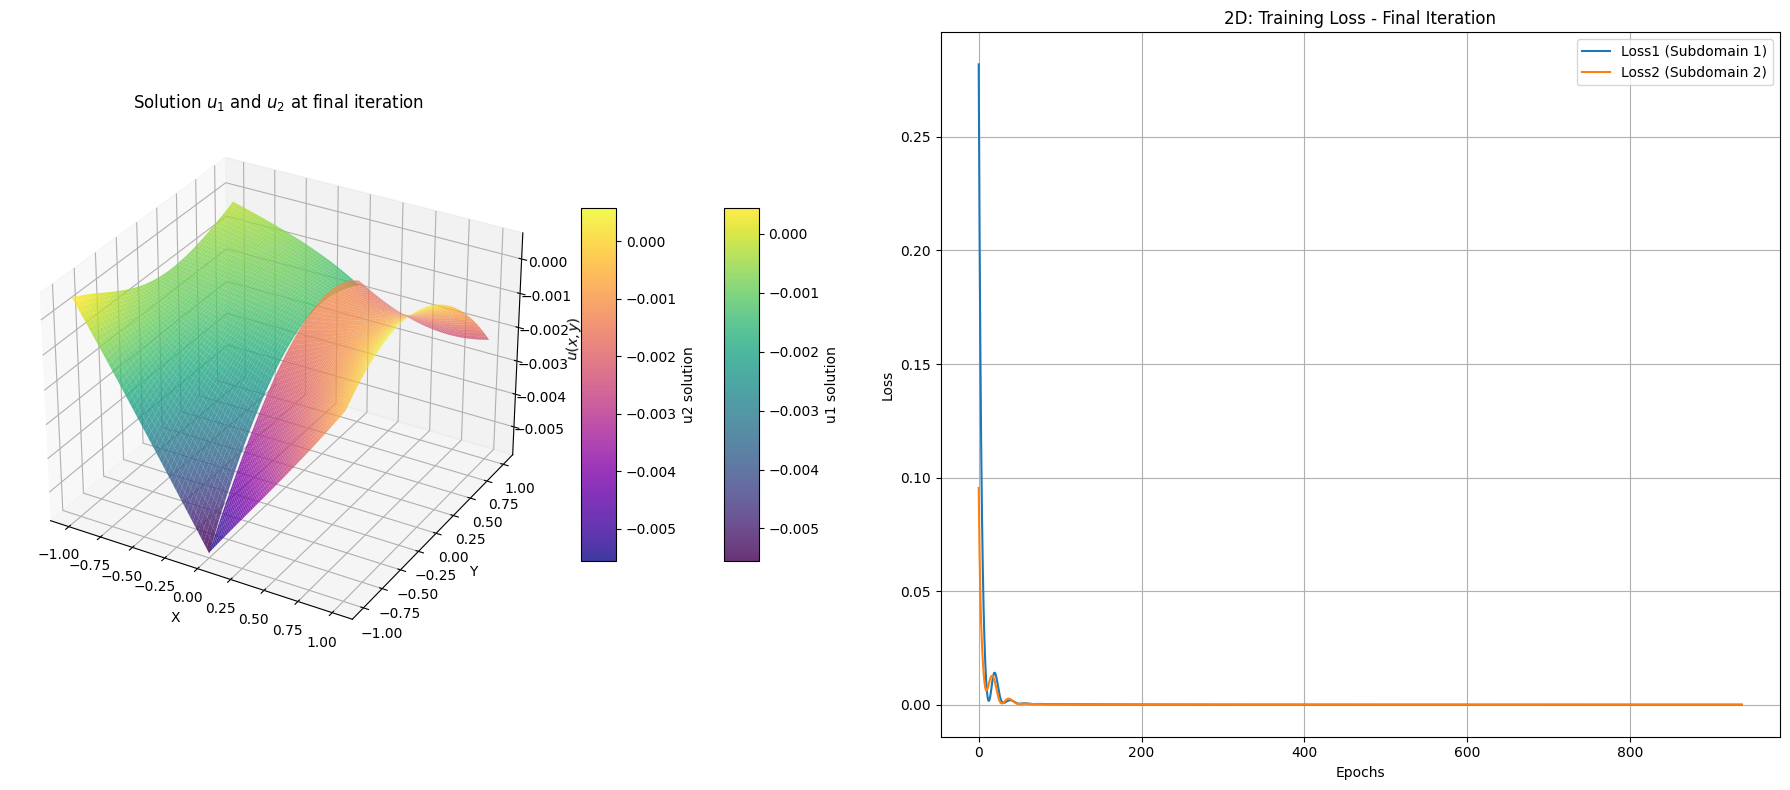

In [21]:
## Last iteration
u1_pred = model1(x1_test_tensor).detach().numpy()
u2_pred = model2(x2_test_tensor).detach().numpy()

u1_pred = u1_pred.reshape(X_x1.shape)
u2_pred = u2_pred.reshape(X_x2.shape)


# Afficher les deux surfaces sur une seule figure
fig = plt.figure(figsize=(18, 8))
ax1 = fig.add_subplot(121, projection='3d')

# Tracer la première surface
surface1 = ax1.plot_surface(X_x1, Y_x1, u1_pred, cmap='viridis', edgecolor='none', alpha=0.8, label="$u_1$")

# Tracer la deuxième surface
surface2 = ax1.plot_surface(X_x2, Y_x2, u2_pred, cmap='plasma', edgecolor='none', alpha=0.8, label="$u_2$")

# Ajouter les étiquettes et une légende
ax1.set_xlabel('X')
ax1.set_ylabel('Y')
ax1.set_zlabel('$u(x,y)$')
ax1.set_title('Solution $u_1$ and $u_2$ at final iteration')

fig.colorbar(surface1, shrink=0.5, aspect=10, label="u1 solution")
fig.colorbar(surface2, shrink=0.5, aspect=10, label="u2 solution")


ax2 = fig.add_subplot(122)
ax2.plot(losses1, label='Loss1 (Subdomain 1)')
ax2.plot(losses2, label='Loss2 (Subdomain 2)')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Loss')
ax2.set_title('2D: Training Loss - Final Iteration')
ax2.legend()
ax2.grid(True)

# Affichage des graphiques
plt.tight_layout()
plt.show()

